<a href="https://colab.research.google.com/github/lazypotato020/ChatApp/blob/main/HEp2_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HEp-2 Cell Pattern Classification
### EE433 Digital Image Processing — Task 3
This notebook classifies HEp-2 cell staining patterns using image features + Random Forest classifier.

## Step 1: Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Step 2: Install & Import Libraries

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from skimage.feature import graycomatrix, graycoprops, local_binary_pattern
from skimage.measure import regionprops
from skimage.filters import threshold_otsu
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, ConfusionMatrixDisplay
)
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully!')

All libraries imported successfully!


## Step 3: Set Dataset Path

In [ ]:

BASE_PATH = '/content/drive/MyDrive/MIVIA Lab/Main_Dataset'

CELL_IMAGES_PATH = os.path.join(BASE_PATH, 'Cells', 'Cell_Images')
CELL_MASKS_PATH  = os.path.join(BASE_PATH, 'Cells', 'Cell_Masks')
IMAGES_PATH      = os.path.join(BASE_PATH, 'Images')

# Verify paths exist
for p in [CELL_IMAGES_PATH, CELL_MASKS_PATH, IMAGES_PATH]:
    exists = os.path.exists(p)
    print(f'{'OK' if exists else 'NOT FOUND'}: {p}')


OK: /content/drive/MyDrive/MIVIA Lab/Main_Dataset/Cells/Cell_Images
OK: /content/drive/MyDrive/MIVIA Lab/Main_Dataset/Cells/Cell_Masks
OK: /content/drive/MyDrive/MIVIA Lab/Main_Dataset/Images


## Step 4: Load All Labels from CSV Files

In [ ]:
all_records = []

for patient_id in range(1, 29):  # 01 to 28
    folder_name = f'{patient_id:02d}'  # '01', '02', ...
    patient_folder = os.path.join(IMAGES_PATH, folder_name)

    # Find CSV file in this folder
    csv_file = None
    for f in os.listdir(patient_folder):
        if f.endswith('.csv'):
            csv_file = os.path.join(patient_folder, f)
            break

    if csv_file is None:
        print(f'WARNING: No CSV found in {patient_folder}')
        continue

    df = pd.read_csv(csv_file, sep=';')

    # Add patient_id and image path to each row
    df['patient_id']  = folder_name
    df['image_path']  = df['cell_ID'].apply(
        lambda cid: os.path.join(CELL_IMAGES_PATH, folder_name, f'{int(cid):03d}.png')
    )
    df['mask_path'] = df['cell_ID'].apply(
        lambda cid: os.path.join(CELL_MASKS_PATH, folder_name, f'{int(cid):03d}.png')
    )

    all_records.append(df)

# Combine all patients into one dataframe
full_df = pd.concat(all_records, ignore_index=True)

print(f'Total cells loaded: {len(full_df)}')
print(f'Columns: {list(full_df.columns)}')
print(f"\nPattern distribution:")
print(full_df['pattern'].value_counts())


Total cells loaded: 1581
Columns: ['intensity', 'cell_ID', 'seed_pointX', 'seed_pointY', 'object_type', 'pattern', 'minX', 'minY', 'maxX', 'maxY', 'patient_id', 'image_path', 'mask_path']

Pattern distribution:
pattern
homogeneous        330
nucleolar          241
centromere         212
coarse_speckled    210
fine_speckled      208
centromeric        145
cytoplasmatic      110
negative            38
positive            32
Name: count, dtype: int64


## Step 5: Filter Only Regular Cells (Remove Mitotic)
We focus on regular cells with named patterns. Mitotic cells have label 'positive' which is not a staining pattern.

In [ ]:
# Keep only regular cells, drop mitotic cells
df_cells = full_df[full_df['object_type'] == 'cell'].copy()
df_cells = df_cells[df_cells['pattern'] != 'positive'].copy()
df_cells = df_cells.reset_index(drop=True)

print(f'Cells after filtering: {len(df_cells)}')
print(f"\nFinal class distribution:")
print(df_cells['pattern'].value_counts())


Cells after filtering: 1456

Final class distribution:
pattern
homogeneous        330
nucleolar          241
centromere         212
coarse_speckled    210
fine_speckled      208
centromeric        145
cytoplasmatic      110
Name: count, dtype: int64


## Step 6: Visualize Sample Cells from Each Class

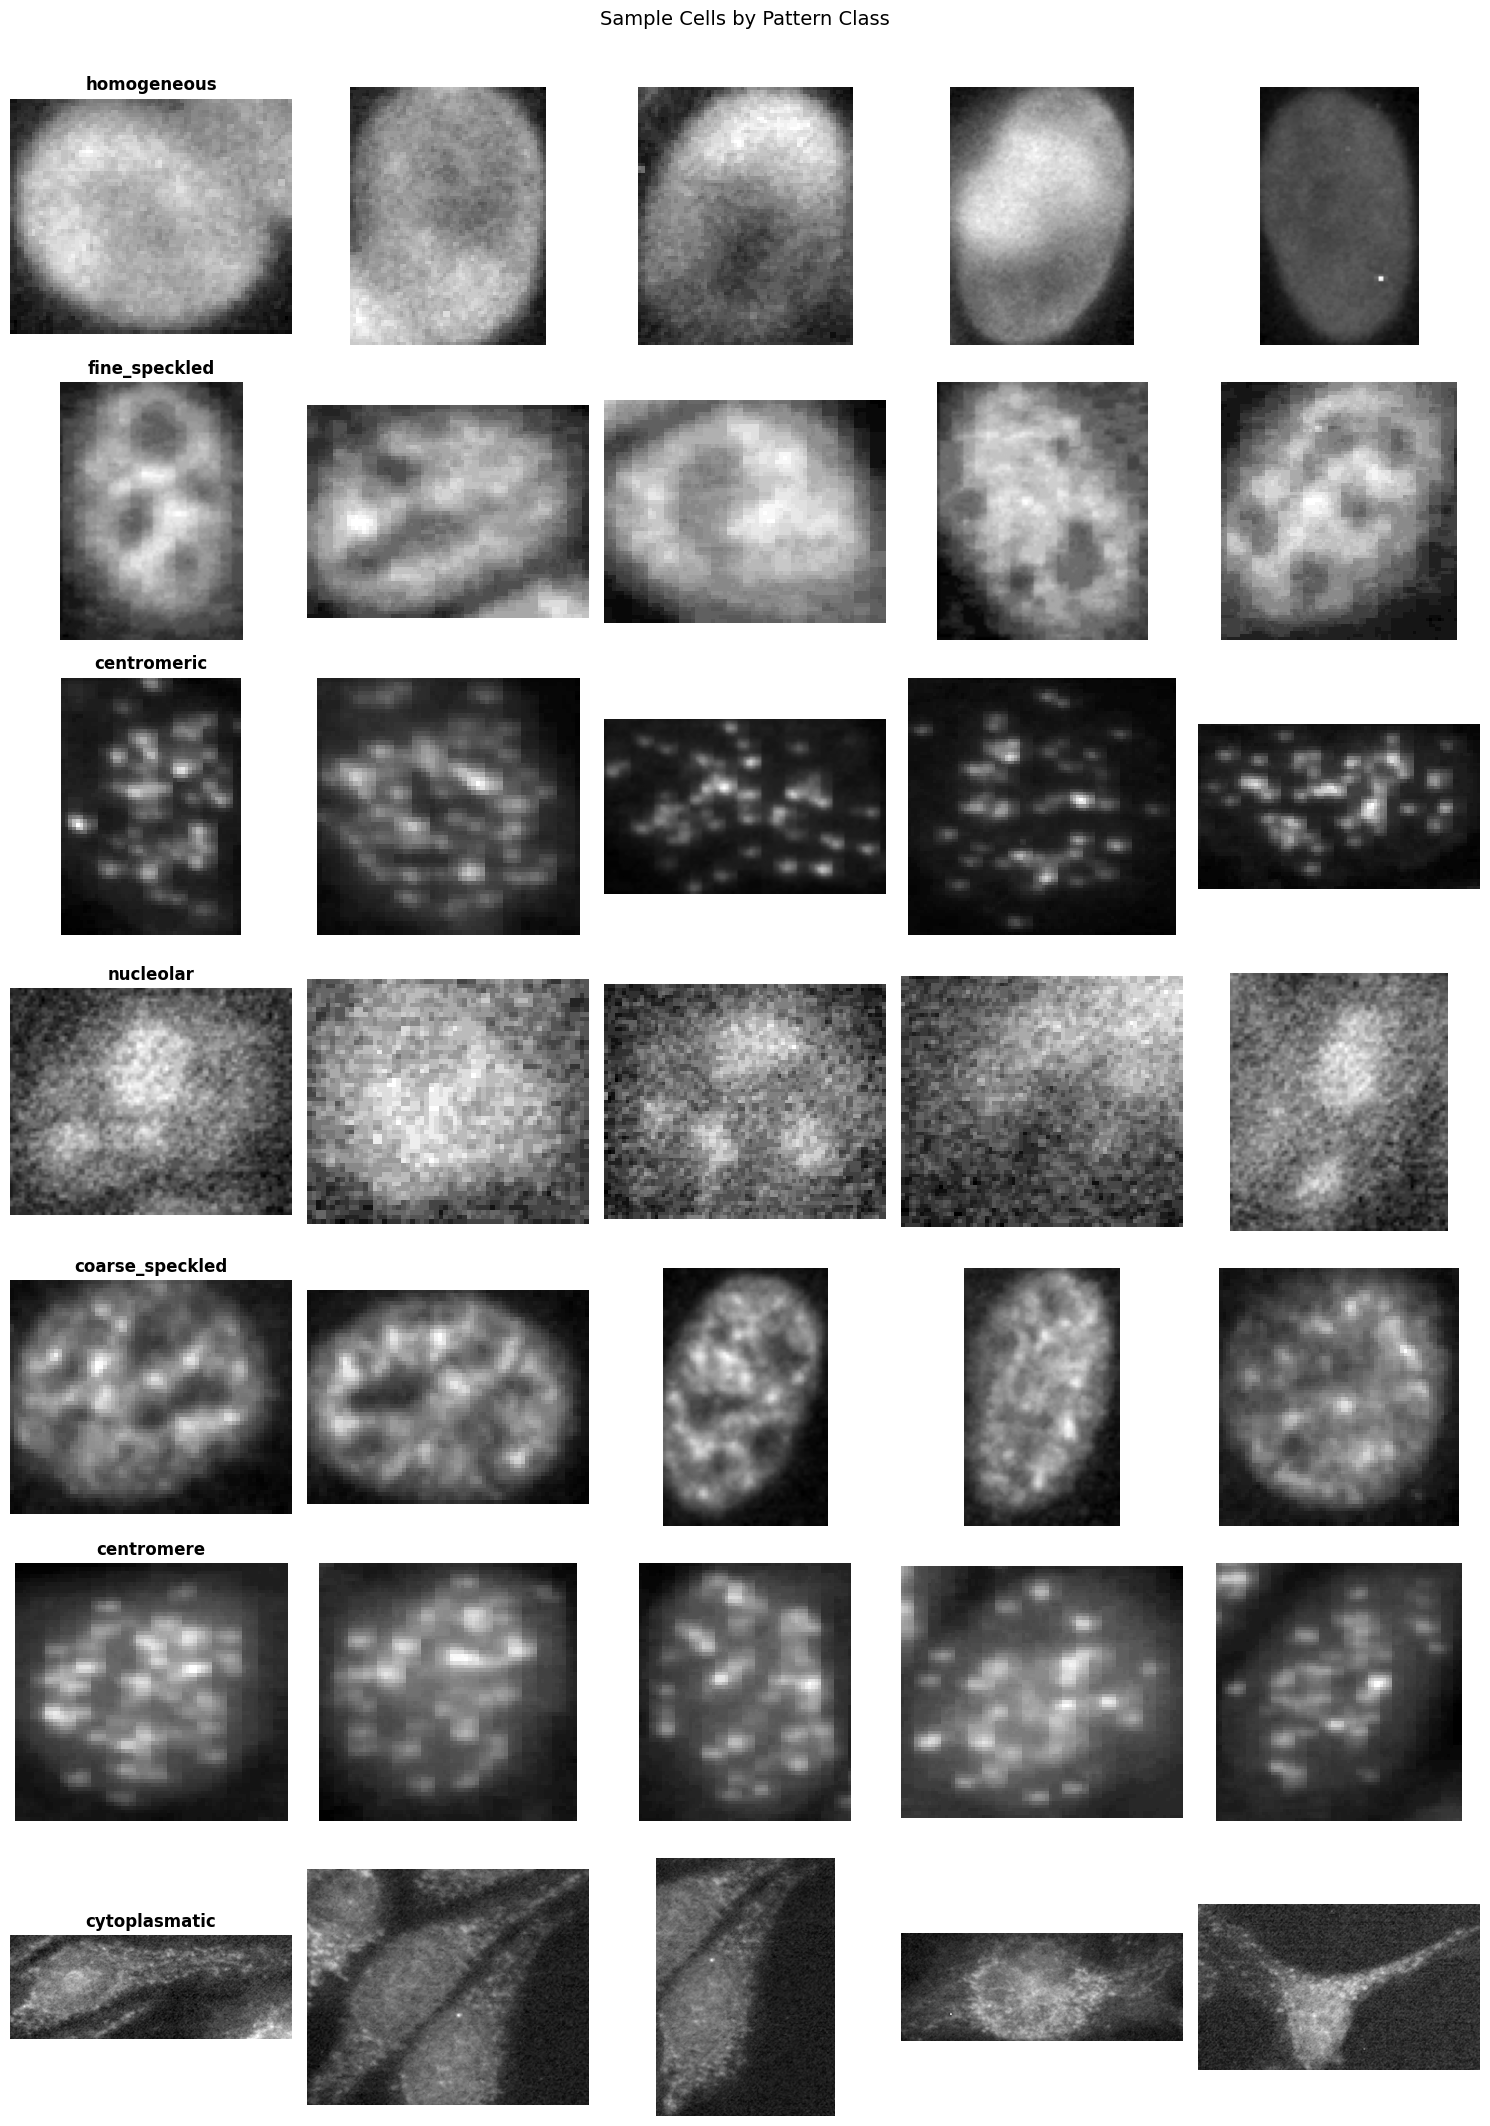

Sample visualization saved!


In [ ]:
classes = df_cells['pattern'].unique()
fig, axes = plt.subplots(len(classes), 5, figsize=(15, 3 * len(classes)))

for i, cls in enumerate(classes):
    samples = df_cells[df_cells['pattern'] == cls].head(5)
    for j, (_, row) in enumerate(samples.iterrows()):
        img = cv2.imread(row['image_path'], cv2.IMREAD_GRAYSCALE)
        if img is not None:
            axes[i][j].imshow(img, cmap='gray')
            axes[i][j].axis('off')
            if j == 0:
                axes[i][j].set_title(cls, fontsize=12, fontweight='bold')

plt.suptitle('Sample Cells by Pattern Class', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('sample_cells.png', bbox_inches='tight', dpi=100)
plt.show()
print('Sample visualization saved!')


## Step 7: Feature Extraction
We extract 3 types of features from each cell image:
- **GLCM (Gray-Level Co-occurrence Matrix)** — texture features
- **LBP (Local Binary Pattern)** — local texture/pattern features  
- **Shape/Intensity features** — basic statistical features

In [ ]:
def extract_features(image_path, mask_path, target_size=(64, 64)):
    """
    Extract features from a single cell image.
    Returns a 1D feature vector.
    """
    features = []

    # --- Load image ---
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None

    # --- Resize to standard size ---
    img = cv2.resize(img, target_size)

    # --- Preprocessing: CLAHE contrast enhancement ---
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    img = clahe.apply(img)

    # ===== FEATURE GROUP 1: Intensity Statistics =====
    features.append(np.mean(img))           # mean intensity
    features.append(np.std(img))            # standard deviation
    features.append(np.percentile(img, 25)) # 25th percentile
    features.append(np.percentile(img, 75)) # 75th percentile
    features.append(np.max(img))            # max intensity
    features.append(np.min(img))            # min intensity

    # ===== FEATURE GROUP 2: GLCM Texture Features =====
    # GLCM captures the spatial relationship between pixel intensities
    img_scaled = (img // 16).astype(np.uint8)  # reduce to 16 levels
    glcm = graycomatrix(img_scaled, distances=[1, 3], angles=[0, np.pi/4, np.pi/2],
                        levels=16, symmetric=True, normed=True)
    features.append(graycoprops(glcm, 'contrast').mean())
    features.append(graycoprops(glcm, 'dissimilarity').mean())
    features.append(graycoprops(glcm, 'homogeneity').mean())
    features.append(graycoprops(glcm, 'energy').mean())
    features.append(graycoprops(glcm, 'correlation').mean())
    features.append(graycoprops(glcm, 'ASM').mean())

    # ===== FEATURE GROUP 3: LBP Features =====
    # LBP captures local texture patterns
    radius = 3
    n_points = 8 * radius
    lbp = local_binary_pattern(img, n_points, radius, method='uniform')
    lbp_hist, _ = np.histogram(lbp.ravel(), bins=26, range=(0, 26), density=True)
    features.extend(lbp_hist.tolist())

    # ===== FEATURE GROUP 4: Gradient / Edge Features =====
    sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
    gradient_mag = np.sqrt(sobelx**2 + sobely**2)
    features.append(np.mean(gradient_mag))
    features.append(np.std(gradient_mag))

    return np.array(features, dtype=np.float32)


print('Feature extraction function defined.')
print('Feature groups: Intensity + GLCM + LBP + Gradient')


Feature extraction function defined.
Feature groups: Intensity + GLCM + LBP + Gradient


## Step 8: Extract Features for All Cells

In [ ]:
X = []  # features
y = []  # labels
failed = 0

print(f'Extracting features from {len(df_cells)} cells...')

for idx, row in df_cells.iterrows():
    feat = extract_features(row['image_path'], row['mask_path'])
    if feat is not None:
        X.append(feat)
        y.append(row['pattern'])
    else:
        failed += 1

    if (idx + 1) % 100 == 0:
        print(f'  Processed {idx+1}/{len(df_cells)} cells...')

X = np.array(X)
y = np.array(y)

print(f'\nDone! Feature matrix shape: {X.shape}')
print(f'Labels shape: {y.shape}')
print(f'Failed to load: {failed} cells')
print(f'Feature vector size per cell: {X.shape[1]}')


Extracting features from 1456 cells...
  Processed 100/1456 cells...
  Processed 200/1456 cells...
  Processed 300/1456 cells...
  Processed 400/1456 cells...
  Processed 500/1456 cells...
  Processed 600/1456 cells...
  Processed 700/1456 cells...
  Processed 800/1456 cells...
  Processed 900/1456 cells...
  Processed 1000/1456 cells...
  Processed 1100/1456 cells...
  Processed 1200/1456 cells...
  Processed 1300/1456 cells...
  Processed 1400/1456 cells...

Done! Feature matrix shape: (1455, 40)
Labels shape: (1455,)
Failed to load: 1 cells
Feature vector size per cell: 40


## Step 9: Encode Labels & Split Dataset

In [ ]:
# Encode string labels to numbers
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print('Class mapping:')
for i, cls in enumerate(le.classes_):
    print(f'  {i} -> {cls}')

# Split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Normalize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f'\nTrain samples: {len(X_train)}')
print(f'Test samples:  {len(X_test)}')


Class mapping:
  0 -> centromere
  1 -> centromeric
  2 -> coarse_speckled
  3 -> cytoplasmatic
  4 -> fine_speckled
  5 -> homogeneous
  6 -> nucleolar

Train samples: 1164
Test samples:  291


## Step 10: Train Random Forest Classifier

In [ ]:
# Train Random Forest
clf = RandomForestClassifier(
    n_estimators=200,    # number of trees
    max_depth=None,      # grow full trees
    min_samples_split=2,
    random_state=42,
    n_jobs=-1            # use all CPU cores
)

print('Training Random Forest...')
clf.fit(X_train, y_train)
print('Training complete!')


Training Random Forest...
Training complete!


## Step 11: Evaluate the Model

In [ ]:
# Predict on test set
y_pred = clf.predict(X_test)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print(f'Overall Accuracy: {acc * 100:.2f}%')
print()

# Full classification report
print('Classification Report:')
print('=' * 60)
print(classification_report(
    y_test, y_pred,
    target_names=le.classes_
))


Overall Accuracy: 89.35%

Classification Report:
                 precision    recall  f1-score   support

     centromere       0.86      0.90      0.88        42
    centromeric       0.97      0.97      0.97        29
coarse_speckled       0.95      0.90      0.93        42
  cytoplasmatic       1.00      0.86      0.93        22
  fine_speckled       0.79      0.81      0.80        42
    homogeneous       0.88      0.91      0.90        66
      nucleolar       0.90      0.90      0.90        48

       accuracy                           0.89       291
      macro avg       0.91      0.89      0.90       291
   weighted avg       0.90      0.89      0.89       291



## Step 12: Confusion Matrix (Visual)

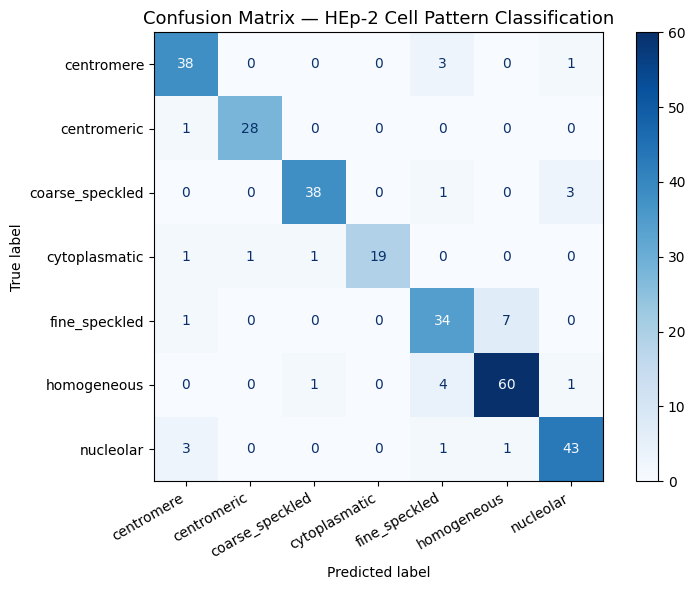

Confusion matrix saved!


In [ ]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, cmap='Blues', colorbar=True)
plt.title('Confusion Matrix — HEp-2 Cell Pattern Classification', fontsize=13)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Confusion matrix saved!')


## Step 13: Feature Importance Plot

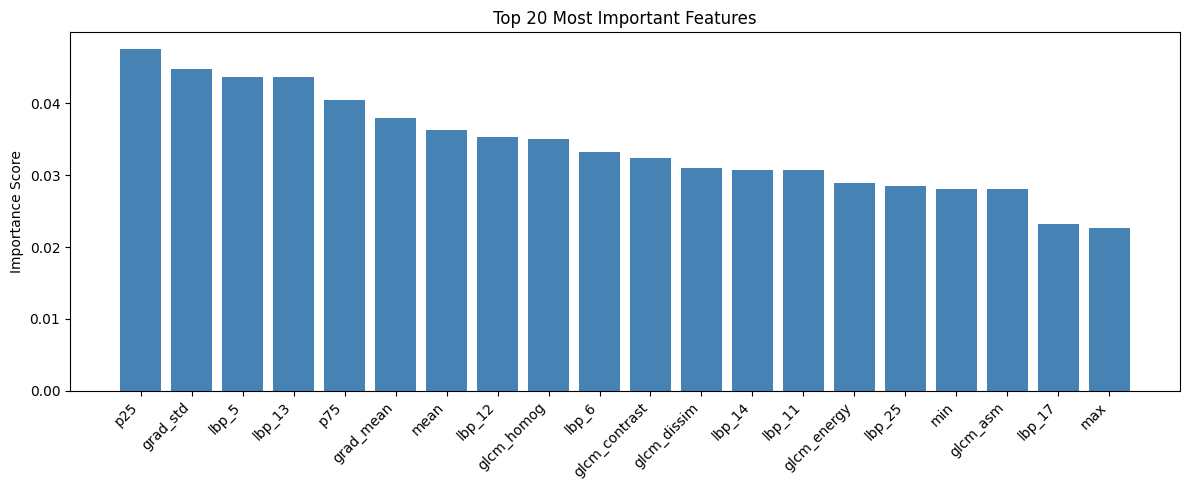

Feature importance plot saved!


In [ ]:
# Feature names for plotting
feat_names = (
    ['mean', 'std', 'p25', 'p75', 'max', 'min'] +
    ['glcm_contrast', 'glcm_dissim', 'glcm_homog', 'glcm_energy', 'glcm_corr', 'glcm_asm'] +
    [f'lbp_{i}' for i in range(26)] +
    ['grad_mean', 'grad_std']
)

importances = clf.feature_importances_
indices = np.argsort(importances)[::-1][:20]  # top 20

plt.figure(figsize=(12, 5))
plt.bar(range(20), importances[indices], color='steelblue')
plt.xticks(range(20), [feat_names[i] for i in indices], rotation=45, ha='right')
plt.title('Top 20 Most Important Features')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Feature importance plot saved!')


## Step 14: Visualize Predictions on Sample Cells

In [ ]:
# Pick 10 random test samples and show prediction vs ground truth
test_indices = np.random.choice(len(X_test), 10, replace=False)

# We need original image paths for visualization
# Rebuild test image paths
all_paths = []
all_labels_str = []
for idx, row in df_cells.iterrows():
    feat = extract_features(row['image_path'], row['mask_path'])
    if feat is not None:
        all_paths.append(row['image_path'])
        all_labels_str.append(row['pattern'])

# Use sklearn indices mapping
from sklearn.model_selection import train_test_split as tts
indices_all = np.arange(len(all_paths))
_, test_idx = tts(indices_all, test_size=0.2, random_state=42,
                  stratify=le.transform(all_labels_str))

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i, ti in enumerate(test_indices):
    orig_idx = test_idx[ti]
    img = cv2.imread(all_paths[orig_idx], cv2.IMREAD_GRAYSCALE)
    true_label = le.classes_[y_test[ti]]
    pred_label = le.classes_[y_pred[ti]]
    correct = true_label == pred_label

    axes[i].imshow(img, cmap='gray')
    axes[i].axis('off')
    color = 'green' if correct else 'red'
    axes[i].set_title(
        f'True: {true_label}\nPred: {pred_label}',
        fontsize=9, color=color
    )

plt.suptitle('Sample Predictions (Green=Correct, Red=Wrong)', fontsize=12)
plt.tight_layout()
plt.savefig('sample_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sample predictions saved!')


NameError: name 'np' is not defined

## Step 15: Summary Report

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

print('=' * 55)
print('       FINAL RESULTS SUMMARY')
print('=' * 55)
print(f'  Dataset       : MIVIA HEp-2 (28 patients)')
print(f'  Total Cells   : {len(X)}')
print(f'  Train / Test  : {len(X_train)} / {len(X_test)}')
print(f'  Classes       : {list(le.classes_)}')
print(f'  Classifier    : Random Forest (200 trees)')
print(f'  Features      : Intensity + GLCM + LBP + Gradient')
print('-' * 55)
print(f'  Accuracy      : {accuracy_score(y_test, y_pred)*100:.2f}%')
print(f'  Precision     : {precision_score(y_test, y_pred, average="weighted")*100:.2f}%')
print(f'  Recall        : {recall_score(y_test, y_pred, average="weighted")*100:.2f}%')
print(f'  F1 Score      : {f1_score(y_test, y_pred, average="weighted")*100:.2f}%')
print('=' * 55)


       FINAL RESULTS SUMMARY
  Dataset       : MIVIA HEp-2 (28 patients)
  Total Cells   : 1455
  Train / Test  : 1164 / 291
  Classes       : [np.str_('centromere'), np.str_('centromeric'), np.str_('coarse_speckled'), np.str_('cytoplasmatic'), np.str_('fine_speckled'), np.str_('homogeneous'), np.str_('nucleolar')]
  Classifier    : Random Forest (200 trees)
  Features      : Intensity + GLCM + LBP + Gradient
-------------------------------------------------------
  Accuracy      : 89.35%
  Precision     : 89.56%
  Recall        : 89.35%
  F1 Score      : 89.39%
